In [3]:
import os
import random
import shutil
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\khale\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Phase 1

In [4]:
from pathlib import Path

# Print directory structure (folders only, 5 levels deep)
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.replace("/kaggle/input", "").count(os.sep)
    if depth <= 5:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/")

In [5]:
# Collect all image paths with their metadata
dataset_root = Path("BreaKHis_v1")

data = []  # each entry: (path, magnification, tumor_type, subtype, patient_id)

for img_path in dataset_root.rglob("*.png"):
    parts = img_path.parts
    
    # Extract tumor class from path
    if "benign" in str(img_path).lower():
        tumor_class = "benign"
    elif "malignant" in str(img_path).lower():
        tumor_class = "malignant"
    else:
        continue
    
    # Extract magnification from path
    mag = None
    for part in parts:
        if part in ["40X", "100X", "200X", "400X"]:
            mag = part
            break
    
    # Extract patient ID from filename
    # Format: SOB_B_A-14-22549AB-40-001 → patient = 14-22549AB
    filename = img_path.stem
    fname_parts = filename.split("-")
    if len(fname_parts) >= 3:
        patient_id = fname_parts[1] + "-" + fname_parts[2]
    else:
        patient_id = filename
    
    data.append({
        "path": img_path,
        "class": tumor_class,
        "magnification": mag,
        "patient_id": patient_id
    })

print(f"Total images found: {len(data)}")

Total images found: 7909


In [9]:
from collections import Counter

classes = [d["class"] for d in data]
mags = [d["magnification"] for d in data]
patients = set(d["patient_id"] for d in data)

print("=== Class Distribution ===")
for cls, count in Counter(classes).items():
    print(f"  {cls}: {count} images")

print(f"\n=== Magnification Distribution ===")
for mag, count in sorted(Counter(mags).items()):
    print(f"  {mag}: {count} images")

print(f"\n=== Unique Patients: {len(patients)} ===")

print(f"\n=== Class x Magnification ===")
cross = Counter((d["class"], d["magnification"]) for d in data)
for (cls, mag), count in sorted(cross.items()):
    print(f"  {cls} @ {mag}: {count}")

=== Class Distribution ===
  benign: 2480 images
  malignant: 5429 images

=== Magnification Distribution ===
  100X: 2081 images
  200X: 2013 images
  400X: 1820 images
  40X: 1995 images

=== Unique Patients: 81 ===

=== Class x Magnification ===
  benign @ 100X: 644
  benign @ 200X: 623
  benign @ 400X: 588
  benign @ 40X: 625
  malignant @ 100X: 1437
  malignant @ 200X: 1390
  malignant @ 400X: 1232
  malignant @ 40X: 1370


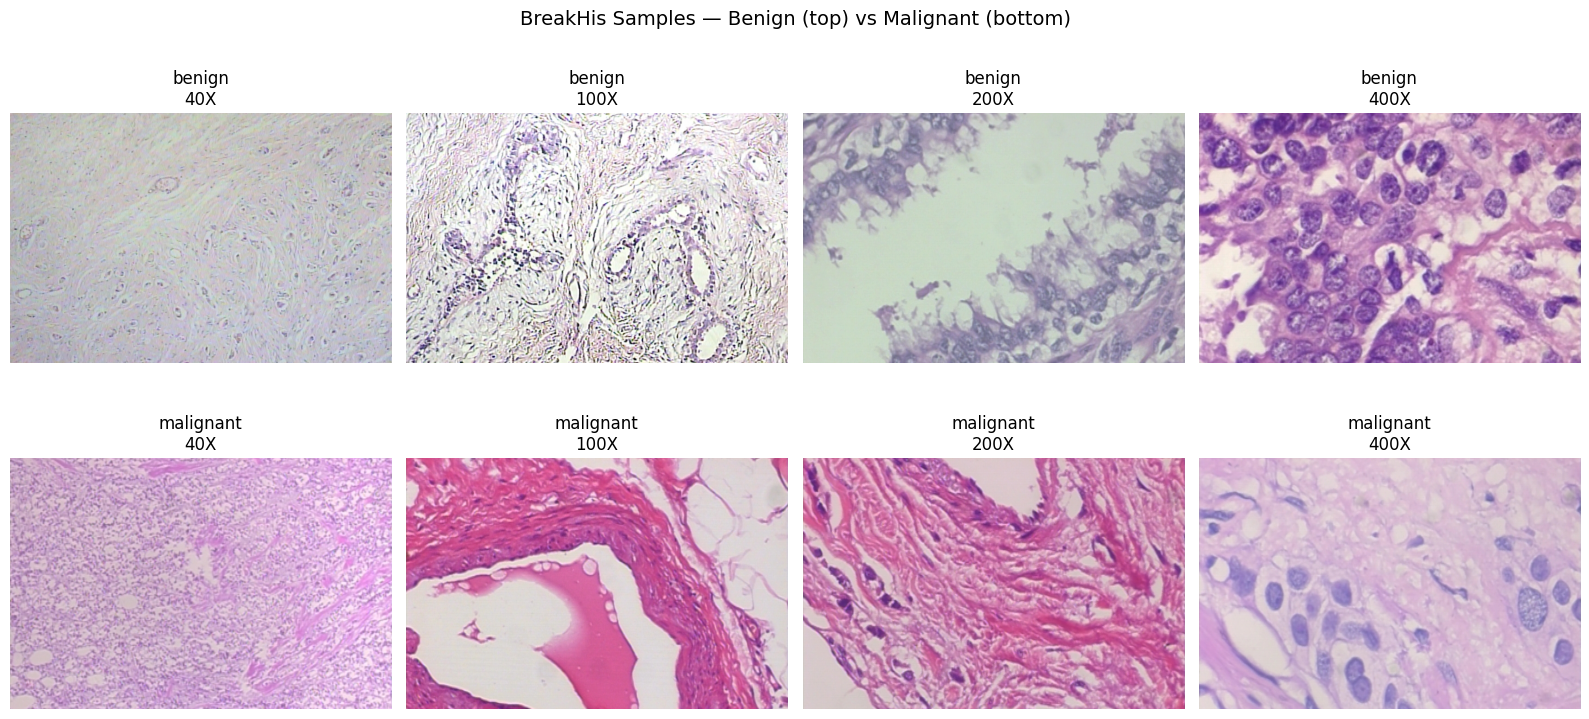

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("BreakHis Samples — Benign (top) vs Malignant (bottom)", fontsize=14)

magnifications = ["40X", "100X", "200X", "400X"]

for col, mag in enumerate(magnifications):
    for row, cls in enumerate(["benign", "malignant"]):
        samples = [d for d in data if d["class"] == cls and d["magnification"] == mag]
        sample = random.choice(samples)
        img = mpimg.imread(sample["path"])
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{cls}\n{mag}")
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Group images by patient ID
from collections import defaultdict

patients_data = defaultdict(list)
for d in data:
    patients_data[d["patient_id"]].append(d)

# Separate patients by class
benign_patients = [p for p in patients_data if any(d["class"] == "benign" for d in patients_data[p])]
malignant_patients = [p for p in patients_data if any(d["class"] == "malignant" for d in patients_data[p])]

print(f"Benign patients:    {len(benign_patients)}")
print(f"Malignant patients: {len(malignant_patients)}")
print(f"Total patients:     {len(benign_patients) + len(malignant_patients)}")

Benign patients:    24
Malignant patients: 57
Total patients:     81


In [10]:
random.seed(42)

def split_patients(patient_list, train_ratio=0.8, val_ratio=0.1):
    random.shuffle(patient_list)
    n = len(patient_list)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return patient_list[:train_end], patient_list[train_end:val_end], patient_list[val_end:]

benign_train, benign_val, benign_test = split_patients(benign_patients)
malignant_train, malignant_val, malignant_test = split_patients(malignant_patients)

print("=== Patient Split ===")
print(f"  Train — benign: {len(benign_train)}, malignant: {len(malignant_train)}")
print(f"  Val   — benign: {len(benign_val)},  malignant: {len(malignant_val)}")
print(f"  Test  — benign: {len(benign_test)},  malignant: {len(malignant_test)}")

=== Patient Split ===
  Train — benign: 19, malignant: 45
  Val   — benign: 2,  malignant: 6
  Test  — benign: 3,  malignant: 6


In [19]:
output_root = Path("/kaggle/working/dataset")

# Map each patient to their split
patient_split = {}
for p in benign_train + malignant_train:
    patient_split[p] = "train"
for p in benign_val + malignant_val:
    patient_split[p] = "val"
for p in benign_test + malignant_test:
    patient_split[p] = "test"

# Copy images into YOLO structure, separated by magnification
copied = 0
skipped = 0

for d in data:
    pid = d["patient_id"]
    split = patient_split.get(pid)
    mag = d["magnification"]
    cls = d["class"]

    if split is None or mag is None:
        skipped += 1
        continue

    # Path: /kaggle/working/dataset/40X/train/benign/image.png
    dest_dir = output_root / mag / split / cls
    dest_dir.mkdir(parents=True, exist_ok=True)

    shutil.copy(d["path"], dest_dir / d["path"].name)
    copied += 1

print(f"Copied:  {copied} images")
print(f"Skipped: {skipped} images")

Copied:  7909 images
Skipped: 0 images


In [20]:
print("=== Final Dataset Structure ===")
for mag in ["40X", "100X", "200X", "400X"]:
    print(f"\n{mag}:")
    for split in ["train", "val", "test"]:
        for cls in ["benign", "malignant"]:
            path = output_root / mag / split / cls
            count = len(list(path.glob("*.png"))) if path.exists() else 0
            print(f"  {split}/{cls}: {count} images")

=== Final Dataset Structure ===

40X:
  train/benign: 501 images
  train/malignant: 1100 images
  val/benign: 51 images
  val/malignant: 117 images
  test/benign: 73 images
  test/malignant: 153 images

100X:
  train/benign: 521 images
  train/malignant: 1173 images
  val/benign: 48 images
  val/malignant: 133 images
  test/benign: 75 images
  test/malignant: 131 images

200X:
  train/benign: 507 images
  train/malignant: 1156 images
  val/benign: 47 images
  val/malignant: 119 images
  test/benign: 69 images
  test/malignant: 115 images

400X:
  train/benign: 490 images
  train/malignant: 1021 images
  val/benign: 39 images
  val/malignant: 103 images
  test/benign: 59 images
  test/malignant: 108 images


In [21]:
from ultralytics import YOLO

results_summary = {}

magnifications = ["40X", "100X", "200X", "400X"]

for mag in magnifications:
    print(f"\n{'='*40}")
    print(f"Training on {mag}...")
    print(f"{'='*40}")
    
    data_path = output_root / mag
    
    model = YOLO("yolo26s-cls.pt")  # downloads automatically on first run
    
    results = model.train(
        data=str(data_path),
        epochs=50,
        imgsz=224,
        batch=32,
        patience=15,
        cos_lr=True,
        augment=True,
        project="/kaggle/working/runs",
        name=f"breakhis_{mag}",
        exist_ok=True,
        verbose=False
    )
    
    results_summary[mag] = results
    print(f"✅ {mag} training complete")

print("\n🎉 All models trained!")


Training on 40X...
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/40X, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=breakhis_40X, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

test_results = {}

for mag in magnifications:
    model_path = f"/kaggle/working/runs/breakhis_{mag}/weights/best.pt"
    model = YOLO(model_path)
    
    test_path = output_root / mag / "test"
    
    # Collect predictions
    all_preds = []
    all_labels = []
    all_probs = []
    
    for cls_idx, cls_name in enumerate(["benign", "malignant"]):
        cls_path = test_path / cls_name
        for img_path in cls_path.glob("*.png"):
            result = model(str(img_path), verbose=False)[0]
            probs = result.probs.data.cpu().numpy()
            pred = int(np.argmax(probs))
            all_preds.append(pred)
            all_labels.append(cls_idx)
            all_probs.append(probs[1])  # probability of malignant
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    acc = np.mean(all_preds == all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    
    test_results[mag] = {
        "preds": all_preds,
        "labels": all_labels,
        "probs": all_probs,
        "acc": acc,
        "auc": auc
    }
    
    print(f"\n{'='*40}")
    print(f"{mag} — Test Accuracy: {acc:.4f} ({acc*100:.2f}%) | AUC: {auc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=["benign", "malignant"]))


40X — Test Accuracy: 0.9558 (95.58%) | AUC: 0.9936
              precision    recall  f1-score   support

      benign       0.93      0.93      0.93        73
   malignant       0.97      0.97      0.97       153

    accuracy                           0.96       226
   macro avg       0.95      0.95      0.95       226
weighted avg       0.96      0.96      0.96       226


100X — Test Accuracy: 0.9369 (93.69%) | AUC: 0.9913
              precision    recall  f1-score   support

      benign       0.98      0.84      0.91        75
   malignant       0.92      0.99      0.95       131

    accuracy                           0.94       206
   macro avg       0.95      0.92      0.93       206
weighted avg       0.94      0.94      0.94       206


200X — Test Accuracy: 0.9022 (90.22%) | AUC: 0.9582
              precision    recall  f1-score   support

      benign       0.81      0.96      0.88        69
   malignant       0.97      0.87      0.92       115

    accuracy            

In [22]:
for mag in magnifications:
    model_path = f"/kaggle/working/runs/breakhis_{mag}/weights/best.pt"
    model = YOLO(model_path)
    
    val_path = output_root / mag
    metrics = model.val(data=str(val_path), verbose=False)
    
    acc = metrics.top1  # top-1 accuracy
    print(f"{mag} — Val Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-cls summary (fused): 47 layers, 5,436,690 parameters, 0 gradients, 12.0 GFLOPs
train: /kaggle/working/dataset/40X/train... found 1601 images in 2 classes ✅ 
val: /kaggle/working/dataset/40X/val... found 168 images in 2 classes ✅ 
test: /kaggle/working/dataset/40X/test... found 226 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4853.1±1466.1 MB/s, size: 847.6 KB)
val: Scanning /kaggle/working/dataset/40X/val... 168 images, 0 corrupt: 100% ━━━━━━━━━━━━ 168/168 58.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 11/11 7.5it/s 1.5s.3s
                   all      0.946          1
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val
40X — Val Accuracy: 0.9464 (94.64%)
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-cls summary (f

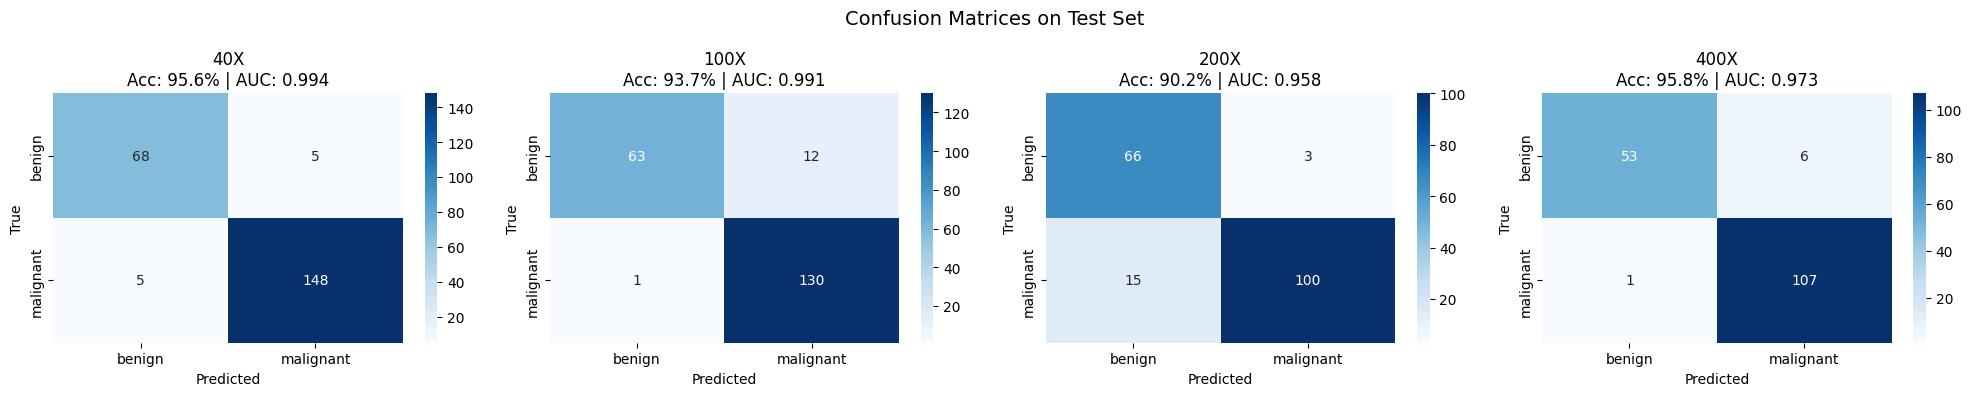

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Confusion Matrices on Test Set", fontsize=14)

for i, mag in enumerate(magnifications):
    cm = confusion_matrix(test_results[mag]["labels"], test_results[mag]["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["benign", "malignant"],
                yticklabels=["benign", "malignant"])
    axes[i].set_title(f"{mag}\nAcc: {test_results[mag]['acc']*100:.1f}% | AUC: {test_results[mag]['auc']:.3f}")
    axes[i].set_ylabel("True")
    axes[i].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [25]:
print("\n========== FINAL RESULTS SUMMARY ==========")
print(f"{'Mag':<8} {'Test Acc':>10} {'AUC':>8}")
print("-" * 30)
for mag in magnifications:
    acc = test_results[mag]['acc']
    auc = test_results[mag]['auc']
    print(f"{mag:<8} {acc*100:>9.2f}% {auc:>8.4f}")
print("=" * 30)
avg_acc = np.mean([test_results[m]['acc'] for m in magnifications])
avg_auc = np.mean([test_results[m]['auc'] for m in magnifications])
print(f"{'Average':<8} {avg_acc*100:>9.2f}% {avg_auc:>8.4f}")


========== FINAL RESULTS SUMMARY ==========
Mag        Test Acc      AUC
------------------------------
40X          95.58%   0.9936
100X         93.69%   0.9913
200X         90.22%   0.9582
400X         95.81%   0.9733
Average      93.82%   0.9791
